In [1]:
%load_ext autoreload
%autoreload 2


# 06b — Barycenter Baseline Comparison

Evaluates the proposed method, an ablation, and six baselines on the symbolic cooking
sequences, each scored by its **own native distance** through the shared harness
(`smartflat.features.symbolic_barycenter.baselines`):

| Method | Barycenter | Native distance |
|--------|-----------|-----------------|
| **TW-TWE + DBA** (proposed) | aeon TWE-DBA | rTWE + Wasserstein cost `D_G` |
| **TWE (ordinal cost)** (ablation) | aeon TWE-DBA (same) | rTWE + ordinal `|i-j|` cost |
| DBA + standard DTW | `barycenter_dba_dtw` | DTW on `D_G` embedding |
| Soft-DTW barycenter | `barycenter_soft_dtw` | Soft-DTW on `D_G` embedding |
| Edit-distance median | `barycenter_edit_median` | Levenshtein |
| Wasserstein barycenter | `barycenter_wasserstein` | EMD between histograms |
| k-Medoid (TW-TWE) | medoid of `D_twe` | rTWE + `D_G` |
| Majority voting | per-step mode | Hamming |

The proposed and ablation methods share one barycenter and differ only in the scoring
ground cost — isolating the Wasserstein contribution (sanity gate below).

**Protocol:** 10 random 50/50 stratified splits × 3 inits; AUC-ROC per pairwise comparison,
plus a pooled **Patient-vs-Control** pass. The embedding-based DTW baselines run at a reduced
split budget (pure-Python cost). Significance: paired Wilcoxon signed-rank + Benjamini-Hochberg.

**Prerequisites:** Run NB06 first to generate `$DATA_ROOT/outputs/symbolic_barycenter/`.

In [2]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap
from IPython.display import display
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

from aeon.clustering.averaging import elastic_barycenter_average

from smartflat.utils.utils_io import get_data_root
from smartflat.utils.utils_visualization import get_base_colors
from smartflat.features.symbolic_barycenter.baselines import (
    evaluate_baselines,
    default_baseline_methods,
    dist_rtwe,
    dist_neg_pmatch,
    pmatch_to_barycenter,
    ordinal_cost_matrix,
    make_patient_control_labels,
    baseline_significance_tests,
    barycenter_mode_dba,
    barycenter_dba_dtw,
    barycenter_soft_dtw,
    barycenter_edit_median,
    barycenter_wasserstein,
    barycenter_k_medoid,
    barycenter_majority_voting,
    embed_symbolic_to_real,
    project_real_to_symbolic,
)


In [3]:
# Load precomputed outputs from NB06
data_root = get_data_root()
out_dir = os.path.join(data_root, 'outputs', 'symbolic_barycenter')

D_twe = np.load(os.path.join(out_dir, 'D_twe.npy'))
D_G = np.load(os.path.join(out_dir, 'D_G.npy'))   # effective ground cost (selected delta applied)
X_aeon = np.load(os.path.join(out_dir, 'X_aeon.npy'))

with open(os.path.join(out_dir, 'barycenters.pkl'), 'rb') as f:
    barycenters_twtwe = pickle.load(f)
with open(os.path.join(out_dir, 'split_data.pkl'), 'rb') as f:
    split_data = pickle.load(f)
with open(os.path.join(out_dir, 'hyperparameters.json')) as f:
    hp = json.load(f)

# Hyperparameters selected in NB06 (must match the D_twe / D_G that were saved)
nu, lmbda, delta = hp['nu'], hp['lmbda'], hp['delta']

# Extract symbolic sequences: X_aeon is (N, 1, L) -> X_symbolic is (N, L)
X_symbolic = X_aeon[:, 0, :].astype(np.int64)
N, T = X_symbolic.shape
G = D_G.shape[0]
assert X_symbolic.min() >= 0 and X_symbolic.max() < G, (X_symbolic.min(), X_symbolic.max(), G)

# Reconstruct full labels array from split_data
labels = np.empty(N, dtype=object)
labels[split_data['train_idx']] = split_data['pathologie_train']
labels[split_data['test_idx']] = split_data['pathologie_test']
assert not any(l is None for l in labels), "Missing labels"

print(f"Sequences: {N} × {T} symbols (G={G})")
print(f"Hyperparameters: nu={nu:g}, lmbda={lmbda:g}, delta={delta:g}")
print(f"D_twe: {D_twe.shape}   D_G: {D_G.shape}")
print(f"Groups: {dict(zip(*np.unique(labels, return_counts=True)))}")
print(f"Precomputed TW-TWE barycenters: {list(barycenters_twtwe.keys())}")


Sequences: 120 × 64 symbols (G=77)
Hyperparameters: nu=0, lmbda=0.5, delta=0.3
D_twe: (120, 120)   D_G: (77, 77)
Groups: {'HEALTHY': 24, 'RIL': 37, 'TBI': 59}
Precomputed TW-TWE barycenters: ['HEALTHY', 'RIL', 'TBI']


### Baseline evaluation

Each method builds its barycenter on the training split only and classifies test sequences
by nearest-group barycenter under its **own native distance** (no leakage; enforced inside
`evaluate_baselines`). We run a pairwise pass (Control / RIL / TBI) and a pooled pass
(Patient vs Control), then concatenate. AUC-ROC is reported as mean ± std over splits × inits.

**Runtime:** the elastic-distance / TWE-DBA methods are fast; the pure-Python embedding-based
DTW baselines (`dba_dtw`, `soft_dtw`) are slow, so they use reduced split budgets and fewer
build iterations (logged). Set `QUICK_MODE = True` for a 2×1 smoke test.

In [4]:
QUICK_MODE = False  # True -> 2 splits x 1 init everywhere (fast smoke test)

# --- Method registry: 6 baselines + proposed variants + ablation ---
methods = default_baseline_methods(D_G, nu=nu, lmbda=lmbda)
D_ord = ordinal_cost_matrix(G)

def build_mode(X_grp, seed):
    """Categorical-correct mode-based DBA (per-aligned-position majority) — the paper's
    described 'mode update' for symbolic data."""
    return barycenter_mode_dba(X_grp, D_G, nu=nu, lmbda=lmbda, max_iter=8, random_state=seed)

def build_mean(X_grp, seed):
    """aeon mean-based TWE-DBA (the mission's literal spec) — averages nominal symbol
    indices, included to document the categorical degeneracy."""
    Xa = X_grp.astype(np.float64)[:, None, :]
    b = elastic_barycenter_average(Xa, method='petitjean', distance='twe', nu=nu, lmbda=lmbda,
                                   init_barycenter='random', max_iters=20, tol=1e-5, random_state=seed)
    return np.clip(np.rint(np.asarray(b).squeeze()).astype(int), 0, G - 1)

# Proposed method, four variants (barycenter: mode vs mean ; feature: p_match vs rTWE distance).
# tw_twe_pmatch (mode-DBA + p_match) is the faithful proposed method (paper's feature).
methods['tw_twe_pmatch'] = {'build': build_mode, 'distance': lambda s, b: dist_neg_pmatch(s, b, D_G, nu=nu, lmbda=lmbda)}
methods['tw_twe']        = {'build': build_mode, 'distance': lambda s, b: dist_rtwe(s, b, D_G, nu=nu, lmbda=lmbda)}
methods['tw_twe_mean']   = {'build': build_mean, 'distance': lambda s, b: dist_rtwe(s, b, D_G, nu=nu, lmbda=lmbda)}
# Ablation: same mode barycenter, ordinal ground cost -> isolates the Wasserstein contribution.
methods['twe_ablation']  = {'build': build_mode, 'distance': lambda s, b: dist_rtwe(s, b, D_ord, nu=nu, lmbda=lmbda)}

# Embedding-based DTW baselines are pure-Python and slow -> reduced iterations / split budget.
methods['dba_dtw']['build']  = lambda Xg, seed: barycenter_dba_dtw(Xg, D_G, max_iters=12, random_state=seed)
methods['soft_dtw']['build'] = lambda Xg, seed: barycenter_soft_dtw(Xg, D_G, max_iter=12, random_state=seed)

FAST = ['tw_twe_pmatch', 'tw_twe', 'tw_twe_mean', 'twe_ablation',
        'k_medoid', 'wasserstein', 'majority_voting', 'edit_median']
if QUICK_MODE:
    FULL = dict(n_splits=2, n_inits=1)
    SLOW_BUDGET = {'dba_dtw': dict(n_splits=2, n_inits=1), 'soft_dtw': dict(n_splits=2, n_inits=1)}
else:
    FULL = dict(n_splits=10, n_inits=3)
    SLOW_BUDGET = {'dba_dtw': dict(n_splits=10, n_inits=3), 'soft_dtw': dict(n_splits=3, n_inits=1)}

pooled_labels = make_patient_control_labels(labels)

def run(method_subset, lab, n_splits, n_inits):
    sub = {k: methods[k] for k in method_subset}
    return evaluate_baselines(X_symbolic, lab, sub, D_pairwise=D_twe,
                              n_splits=n_splits, n_inits=n_inits, random_state=42)

frames = []
print(f"Fast methods {FAST} ({FULL['n_splits']}x{FULL['n_inits']})...", flush=True)
frames.append(run(FAST, labels,        FULL['n_splits'], FULL['n_inits']))
frames.append(run(FAST, pooled_labels, FULL['n_splits'], FULL['n_inits']))
for m, bud in SLOW_BUDGET.items():
    print(f"Slow baseline {m} ({bud['n_splits']}x{bud['n_inits']})...", flush=True)
    frames.append(run([m], labels,        bud['n_splits'], bud['n_inits']))
    frames.append(run([m], pooled_labels, bud['n_splits'], bud['n_inits']))

df_all = pd.concat(frames, ignore_index=True)
budget_note = {m: f"{SLOW_BUDGET[m]['n_splits']}x{SLOW_BUDGET[m]['n_inits']}" for m in SLOW_BUDGET}
print(f"\nCollected {len(df_all)} rows across {df_all['method'].nunique()} methods")
print(f"Reduced-budget methods: {budget_note}")
display(df_all.groupby(['method', 'comparison'])['auc'].agg(['mean', 'std', 'count']).round(3))


Fast methods ['tw_twe_pmatch', 'tw_twe', 'tw_twe_mean', 'twe_ablation', 'k_medoid', 'wasserstein', 'majority_voting', 'edit_median'] (10x3)...


2026-06-06 08:33:06.436227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780727586.455040 2723267 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780727586.460937 2723267 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780727586.477268 2723267 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780727586.477284 2723267 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780727586.477286 2723267 computation_placer.cc:177] computation placer alr

Slow baseline dba_dtw (10x3)...
Slow baseline soft_dtw (3x1)...


/home/perochon/smartflat/smartflat/features/symbolic_barycenter/baselines.py:227: RuntimeWarning: divide by zero encountered in log
  softmin = -gamma * np.log(
/home/perochon/smartflat/smartflat/features/symbolic_barycenter/baselines.py:227: RuntimeWarning: divide by zero encountered in log
  softmin = -gamma * np.log(
/home/perochon/smartflat/smartflat/features/symbolic_barycenter/baselines.py:227: RuntimeWarning: divide by zero encountered in log
  softmin = -gamma * np.log(
/home/perochon/smartflat/smartflat/features/symbolic_barycenter/baselines.py:227: RuntimeWarning: divide by zero encountered in log
  softmin = -gamma * np.log(
/home/perochon/smartflat/smartflat/features/symbolic_barycenter/baselines.py:227: RuntimeWarning: divide by zero encountered in log
  softmin = -gamma * np.log(
/home/perochon/smartflat/smartflat/features/symbolic_barycenter/baselines.py:227: RuntimeWarning: divide by zero encountered in log
  softmin = -gamma * np.log(



Collected 1092 rows across 10 methods
Reduced-budget methods: {'dba_dtw': '10x3', 'soft_dtw': '3x1'}


mean    std  count
method          comparison                             
dba_dtw         CONTROL_vs_PATIENT  0.621  0.106     30
                HEALTHY_vs_RIL      0.685  0.119     30
                HEALTHY_vs_TBI      0.543  0.115     30
                RIL_vs_TBI          0.523  0.065     30
edit_median     CONTROL_vs_PATIENT  0.731  0.062     30
                HEALTHY_vs_RIL      0.743  0.075     30
                HEALTHY_vs_TBI      0.576  0.079     30
                RIL_vs_TBI          0.616  0.072     30
k_medoid        CONTROL_vs_PATIENT  0.599  0.079     30
                HEALTHY_vs_RIL      0.652  0.101     30
                HEALTHY_vs_TBI      0.511  0.068     30
                RIL_vs_TBI          0.508  0.080     30
majority_voting CONTROL_vs_PATIENT  0.738  0.052     30
                HEALTHY_vs_RIL      0.764  0.070     30
                HEALTHY_vs_TBI      0.695  0.050     30
                RIL_vs_TBI          0.500  0.061     30
soft_dtw        CONTROL_vs_PATIENT  0.508  0.060      3
                HEALTHY_vs_RIL      0.565  0.093      3
                HEALTHY_vs_TBI      0.524  0.084      3
                RIL_vs_TBI          0.518  0.137      3
tw_twe          CONTROL_vs_PATIENT  0.563  0.122     30
                HEALTHY_vs_RIL      0.727  0.064     30
                HEALTHY_vs_TBI      0.550  0.042     30
                RIL_vs_TBI          0.557  0.068     30
tw_twe_mean     CONTROL_vs_PATIENT  0.515  0.130     30
                HEALTHY_vs_RIL      0.481  0.123     30
                HEALTHY_vs_TBI      0.470  0.102     30
                RIL_vs_TBI          0.528  0.095     30
tw_twe_pmatch   CONTROL_vs_PATIENT  0.577  0.105     30
                HEALTHY_vs_RIL      0.761  0.084     30
                HEALTHY_vs_TBI      0.584  0.105     30
                RIL_vs_TBI          0.540  0.049     30
twe_ablation    CONTROL_vs_PATIENT  0.538  0.083     30
                HEALTHY_vs_RIL      0.566  0.113     30
                HEALTHY_vs_TBI      0.495  0.091     30
                RIL_vs_TBI          0.549  0.084     30
wasserstein     CONTROL_vs_PATIENT  0.718  0.089     30
                HEALTHY_vs_RIL      0.839  0.050     30
                HEALTHY_vs_TBI      0.600  0.043     30
                RIL_vs_TBI          0.594  0.048     30

In [5]:
# --- Sanity gate: the Wasserstein ground cost must change results ---
# tw_twe (rTWE+D_G) and twe_ablation (rTWE+ordinal) share the SAME mode barycenter,
# so any AUC difference is purely the Wasserstein contribution. They MUST differ.
mean_auc = df_all.groupby(['method', 'comparison'])['auc'].mean().unstack('method')
diff = (mean_auc['tw_twe'] - mean_auc['twe_ablation']).abs()
print("|tw_twe - twe_ablation| mean-AUC per comparison:")
print(diff.round(4).to_string())
assert (diff > 1e-6).any(), "SANITY GATE FAILED: D_G did not take (proposed == ablation)."
assert 'tw_twe_pmatch' in set(df_all[df_all['comparison'] == 'CONTROL_vs_PATIENT']['method'])
print("SANITY GATE PASSED.\n")

# --- Categorical-correctness ablation: mode-based vs mean-based (aeon) DBA ---
print("Mean-based (aeon) vs mode-based DBA, rTWE-distance AUC per comparison:")
print(mean_auc.loc[:, ['tw_twe_mean', 'tw_twe']].round(3).to_string())

# --- Significance: paired Wilcoxon + Benjamini-Hochberg, reference = faithful proposed ---
# tw_twe_pmatch (mode-DBA + p_match) is the paper's actual proposed feature.
df_sig = baseline_significance_tests(df_all, reference='tw_twe_pmatch', alpha=0.05)
print(f"\nSignificance (reference = tw_twe_pmatch): {len(df_sig)} comparisons")
display(df_sig.round(4))


|tw_twe - twe_ablation| mean-AUC per comparison:
comparison
CONTROL_vs_PATIENT    0.0247
HEALTHY_vs_RIL        0.1609
HEALTHY_vs_TBI        0.0556
RIL_vs_TBI            0.0079
SANITY GATE PASSED.

Mean-based (aeon) vs mode-based DBA, rTWE-distance AUC per comparison:
method              tw_twe_mean  tw_twe
comparison                             
CONTROL_vs_PATIENT        0.515   0.563
HEALTHY_vs_RIL            0.481   0.727
HEALTHY_vs_TBI            0.470   0.550
RIL_vs_TBI                0.528   0.557

Significance (reference = tw_twe_pmatch): 36 comparisons


,method,comparison,mean_auc,ref_mean_auc,delta,statistic,p_value,p_value_bh,significant
0,dba_dtw,CONTROL_vs_PATIENT,0.6209,0.5773,-0.0435,19.0,0.4316,0.7400,False
1,edit_median,CONTROL_vs_PATIENT,0.7307,0.5773,-0.1534,3.0,0.0098,0.0703,False
2,k_medoid,CONTROL_vs_PATIENT,0.5986,0.5773,-0.0213,24.0,0.7695,0.8395,False
3,majority_voting,CONTROL_vs_PATIENT,0.7383,0.5773,-0.1609,0.0,0.0020,0.0352,True
4,soft_dtw,CONTROL_vs_PATIENT,0.5075,0.5660,0.0584,2.0,0.7500,0.8395,False
5,tw_twe,CONTROL_vs_PATIENT,0.5630,0.5773,0.0143,23.0,0.6953,0.8344,False
6,tw_twe_mean,CONTROL_vs_PATIENT,0.5150,0.5773,0.0624,13.0,0.1602,0.4118,False
7,twe_ablation,CONTROL_vs_PATIENT,0.5384,0.5773,0.0390,21.0,0.5566,0.8036,False
8,wasserstein,CONTROL_vs_PATIENT,0.7175,0.5773,-0.1402,6.0,0.0273,0.1214,False
9,dba_dtw,HEALTHY_vs_RIL,0.6853,0.7610,0.0756,11.0,0.1055,0.3164,False


In [6]:
# --- Paper-facing summary: mean +/- std AUC per (method x comparison) ---
COL_MAP = {
    'CONTROL_vs_PATIENT': 'Patient vs Control',
    'HEALTHY_vs_RIL': 'RIL vs Control',
    'RIL_vs_TBI': 'TBI vs RIL',
}
ROW_ORDER = ['tw_twe_pmatch', 'tw_twe', 'tw_twe_mean', 'twe_ablation',
             'dba_dtw', 'soft_dtw', 'edit_median', 'wasserstein', 'k_medoid', 'majority_voting']

agg = df_all.groupby(['method', 'comparison'])['auc'].agg(['mean', 'std']).reset_index()
agg['cell'] = agg.apply(lambda r: f"{r['mean']:.2f} ± {r['std']:.2f}", axis=1)
table = agg.pivot(index='method', columns='comparison', values='cell')
table = table.reindex(index=[m for m in ROW_ORDER if m in table.index])
table = table[[c for c in COL_MAP if c in table.columns]].rename(columns=COL_MAP)
print("=== Baseline comparison table (mean ± std AUC) ===")
display(table)

# Full per-comparison summary (all comparisons, incl. HEALTHY_vs_TBI)
summary = df_all.groupby(['method', 'comparison'])['auc'].agg(['mean', 'std', 'count']).round(3)
display(summary)


=== Baseline comparison table (mean ± std AUC) ===


comparison,Patient vs Control,RIL vs Control,TBI vs RIL
method,,,
tw_twe_pmatch,0.58 ± 0.10,0.76 ± 0.08,0.54 ± 0.05
tw_twe,0.56 ± 0.12,0.73 ± 0.06,0.56 ± 0.07
tw_twe_mean,0.51 ± 0.13,0.48 ± 0.12,0.53 ± 0.09
twe_ablation,0.54 ± 0.08,0.57 ± 0.11,0.55 ± 0.08
dba_dtw,0.62 ± 0.11,0.69 ± 0.12,0.52 ± 0.06
soft_dtw,0.51 ± 0.06,0.57 ± 0.09,0.52 ± 0.14
edit_median,0.73 ± 0.06,0.74 ± 0.07,0.62 ± 0.07
wasserstein,0.72 ± 0.09,0.84 ± 0.05,0.59 ± 0.05
k_medoid,0.60 ± 0.08,0.65 ± 0.10,0.51 ± 0.08


mean    std  count
method          comparison                             
dba_dtw         CONTROL_vs_PATIENT  0.621  0.106     30
                HEALTHY_vs_RIL      0.685  0.119     30
                HEALTHY_vs_TBI      0.543  0.115     30
                RIL_vs_TBI          0.523  0.065     30
edit_median     CONTROL_vs_PATIENT  0.731  0.062     30
                HEALTHY_vs_RIL      0.743  0.075     30
                HEALTHY_vs_TBI      0.576  0.079     30
                RIL_vs_TBI          0.616  0.072     30
k_medoid        CONTROL_vs_PATIENT  0.599  0.079     30
                HEALTHY_vs_RIL      0.652  0.101     30
                HEALTHY_vs_TBI      0.511  0.068     30
                RIL_vs_TBI          0.508  0.080     30
majority_voting CONTROL_vs_PATIENT  0.738  0.052     30
                HEALTHY_vs_RIL      0.764  0.070     30
                HEALTHY_vs_TBI      0.695  0.050     30
                RIL_vs_TBI          0.500  0.061     30
soft_dtw        CONTROL_vs_PATIENT  0.508  0.060      3
                HEALTHY_vs_RIL      0.565  0.093      3
                HEALTHY_vs_TBI      0.524  0.084      3
                RIL_vs_TBI          0.518  0.137      3
tw_twe          CONTROL_vs_PATIENT  0.563  0.122     30
                HEALTHY_vs_RIL      0.727  0.064     30
                HEALTHY_vs_TBI      0.550  0.042     30
                RIL_vs_TBI          0.557  0.068     30
tw_twe_mean     CONTROL_vs_PATIENT  0.515  0.130     30
                HEALTHY_vs_RIL      0.481  0.123     30
                HEALTHY_vs_TBI      0.470  0.102     30
                RIL_vs_TBI          0.528  0.095     30
tw_twe_pmatch   CONTROL_vs_PATIENT  0.577  0.105     30
                HEALTHY_vs_RIL      0.761  0.084     30
                HEALTHY_vs_TBI      0.584  0.105     30
                RIL_vs_TBI          0.540  0.049     30
twe_ablation    CONTROL_vs_PATIENT  0.538  0.083     30
                HEALTHY_vs_RIL      0.566  0.113     30
                HEALTHY_vs_TBI      0.495  0.091     30
                RIL_vs_TBI          0.549  0.084     30
wasserstein     CONTROL_vs_PATIENT  0.718  0.089     30
                HEALTHY_vs_RIL      0.839  0.050     30
                HEALTHY_vs_TBI      0.600  0.043     30
                RIL_vs_TBI          0.594  0.048     30

### AUC comparison figure

Saved: /home/perochon/data-gold-final/outputs/symbolic_barycenter/baseline_comparison_auc.png


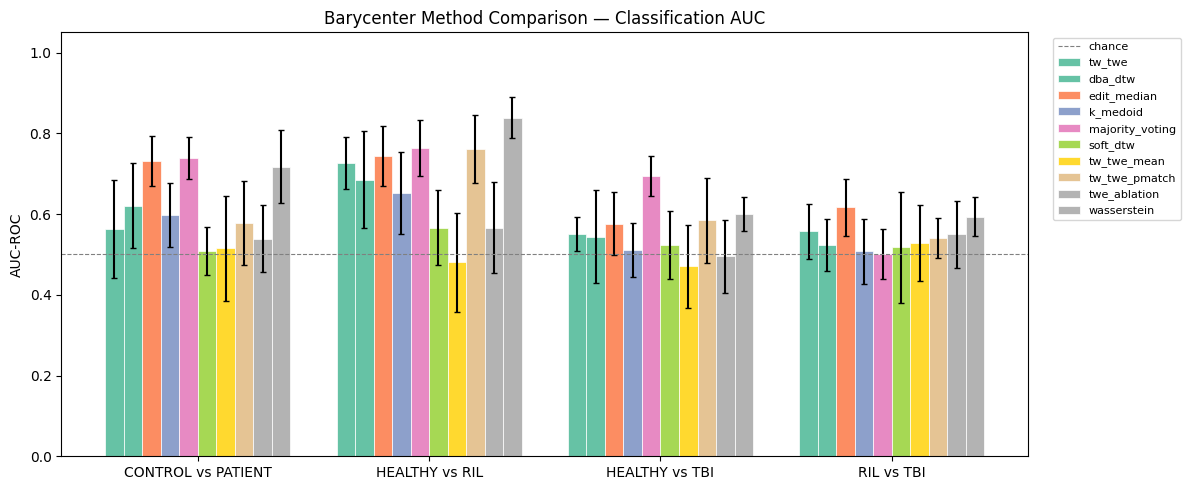

In [7]:
# Grouped bar chart: AUC by method and comparison pair
auc_summary = (
    df_all.groupby(['method', 'comparison'])['auc']
    .agg(['mean', 'std'])
    .reset_index()
)

# Order methods: proposed first, then baselines alphabetically
method_order = ['tw_twe'] + sorted([m for m in df_all['method'].unique() if m != 'tw_twe'])
comparison_order = sorted(df_all['comparison'].unique())

fig, ax = plt.subplots(figsize=(12, 5))
n_methods = len(method_order)
n_comparisons = len(comparison_order)
bar_width = 0.8 / n_methods

colors = plt.cm.Set2(np.linspace(0, 1, n_methods))

for mi, method in enumerate(method_order):
    means, stds, xs = [], [], []
    for ci, comp in enumerate(comparison_order):
        row = auc_summary[(auc_summary['method'] == method) & (auc_summary['comparison'] == comp)]
        if len(row) > 0:
            means.append(row['mean'].values[0])
            stds.append(row['std'].values[0])
        else:
            means.append(0)
            stds.append(0)
        xs.append(ci + mi * bar_width)
    ax.bar(xs, means, bar_width, yerr=stds, label=method, color=colors[mi],
           edgecolor='white', linewidth=0.5, capsize=2)

ax.set_xticks([ci + (n_methods - 1) * bar_width / 2 for ci in range(n_comparisons)])
ax.set_xticklabels([c.replace('_', ' ') for c in comparison_order])
ax.set_ylabel('AUC-ROC')
ax.set_title('Barycenter Method Comparison — Classification AUC')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 1.05)
fig.tight_layout()

fig.savefig(os.path.join(out_dir, 'baseline_comparison_auc.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {os.path.join(out_dir, 'baseline_comparison_auc.png')}")
plt.show()


### Barycenter chronogram visualization

Example barycenters for each method (computed on the first split's training set).
Wasserstein produces a histogram rather than a sequence, shown separately.

Saved: /home/perochon/data-gold-final/outputs/symbolic_barycenter/baseline_chronograms.png


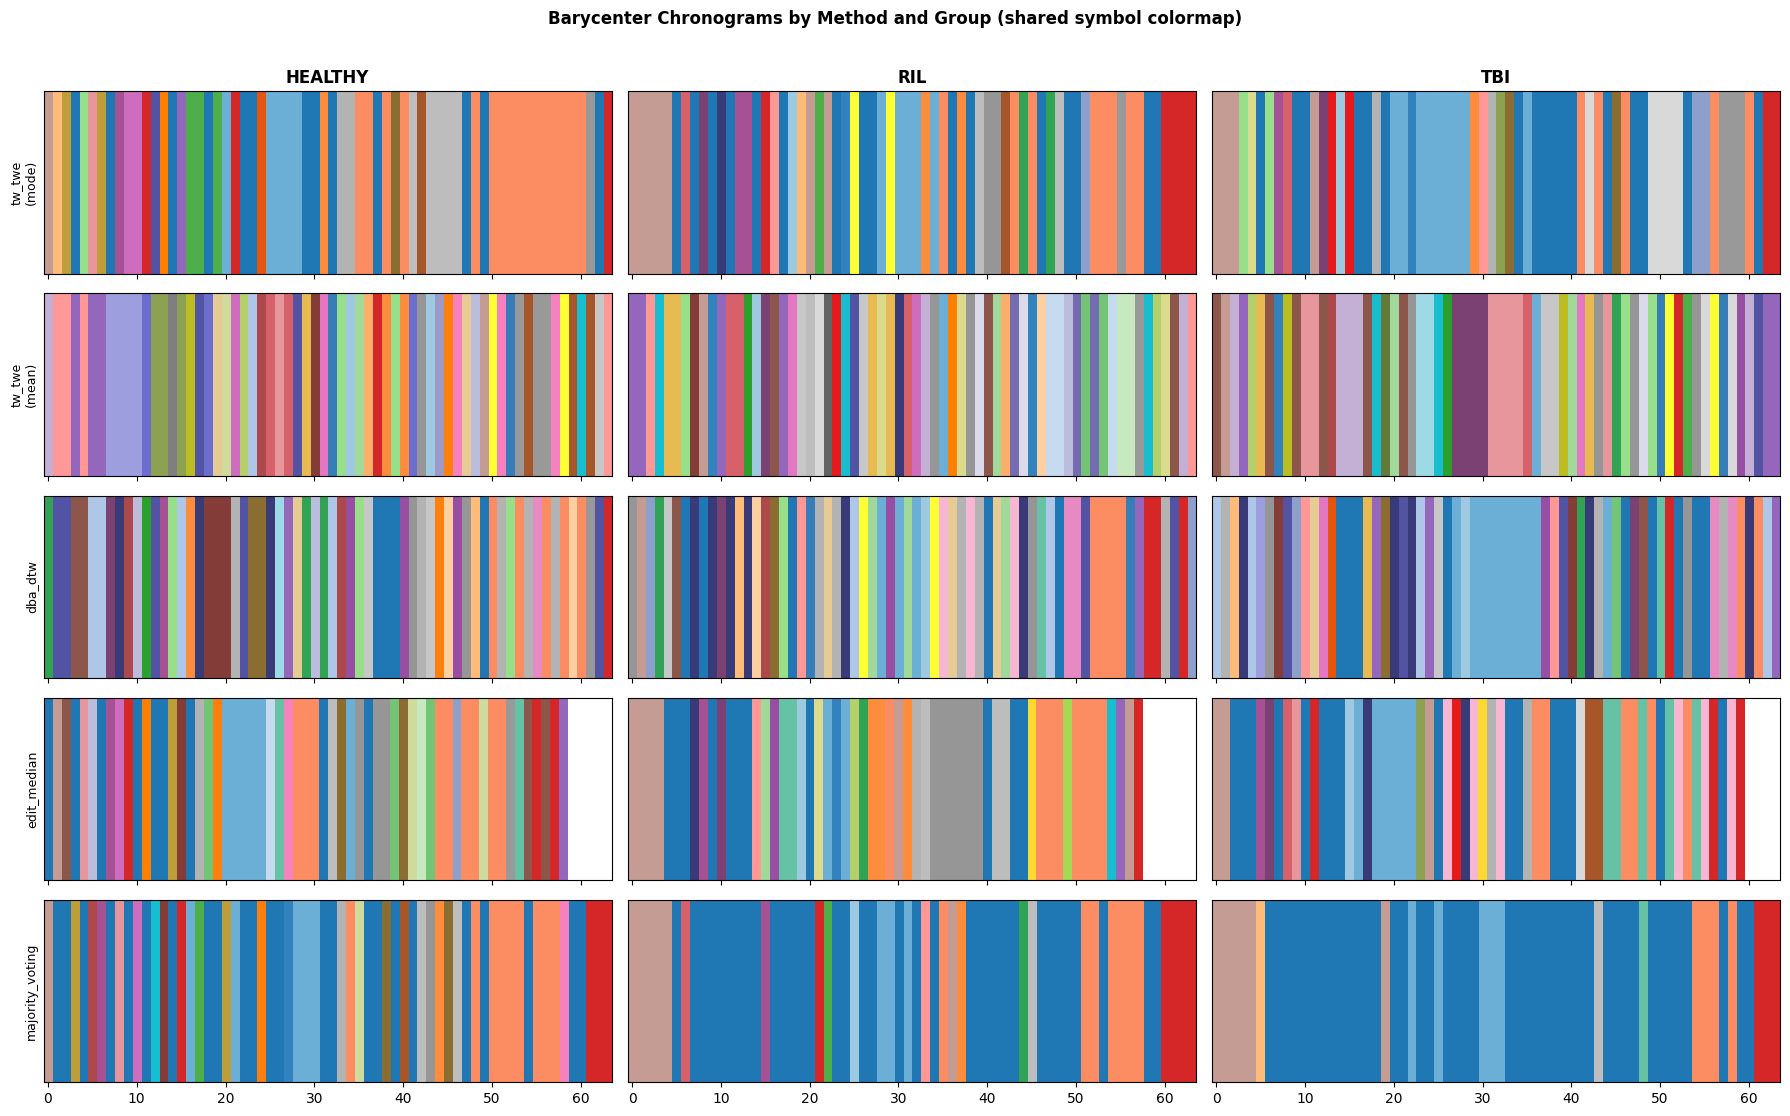

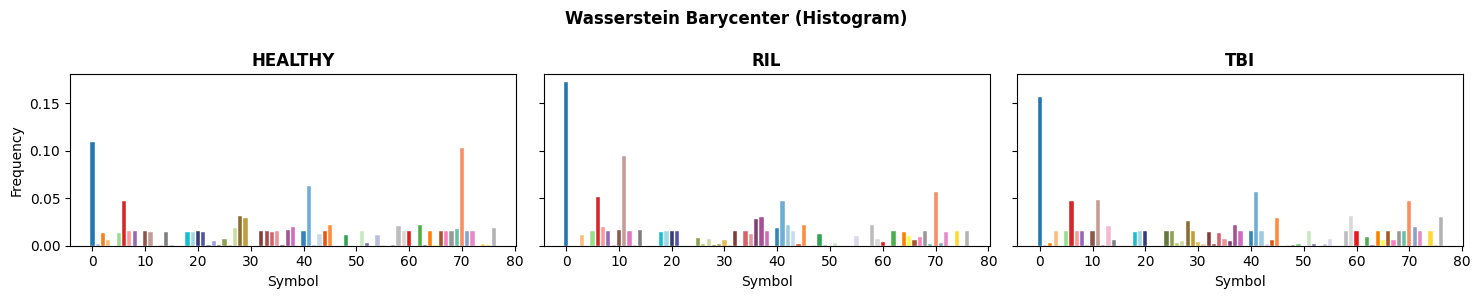

In [8]:
# Compute one example barycenter per group per method (split 0, seed 42) for visualization.
# All chronograms (and the Wasserstein histograms) share ONE categorical symbol colormap
# (get_base_colors over 0..G-1) so a given symbol has the same color in every panel.
try:
    splitter_ex = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    train_idx_ex, _ = next(splitter_ex.split(X_symbolic, labels))
    seed = 42

    groups = sorted(np.unique(labels))
    sym_colors = get_base_colors(G)
    cmap = ListedColormap(sym_colors)
    norm = BoundaryNorm(np.arange(-0.5, G + 0.5), cmap.N)

    seq_methods = {
        'tw_twe (mode)': lambda X, grp: build_mode(X, seed),
        'tw_twe (mean)': lambda X, grp: build_mean(X, seed),
        'dba_dtw': lambda X, grp: barycenter_dba_dtw(X, D_G, max_iters=12, random_state=seed),
        'edit_median': lambda X, grp: barycenter_edit_median(X, n_alphabet=G),
        'majority_voting': lambda X, grp: barycenter_majority_voting(X),
    }

    fig, axes = plt.subplots(len(seq_methods), len(groups),
                             figsize=(18, 2.2 * len(seq_methods)), sharex=True, squeeze=False)
    for mi, (method_name, method_fn) in enumerate(seq_methods.items()):
        for gi, grp in enumerate(groups):
            grp_mask = labels[train_idx_ex] == grp
            X_grp = X_symbolic[train_idx_ex][grp_mask]
            b = np.asarray(method_fn(X_grp, grp)).squeeze().astype(int)
            axes[mi, gi].imshow(b[np.newaxis, :min(len(b), T)], aspect='auto', cmap=cmap,
                                norm=norm, interpolation='nearest')
            axes[mi, gi].set_yticks([])
            if mi == 0:
                axes[mi, gi].set_title(grp, fontweight='bold')
            if gi == 0:
                axes[mi, gi].set_ylabel(method_name.replace(' ', '\n'), fontsize=9)
    fig.suptitle('Barycenter Chronograms by Method and Group (shared symbol colormap)',
                 fontweight='bold', y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, 'baseline_chronograms.png'), dpi=150, bbox_inches='tight')
    print(f"Saved: {os.path.join(out_dir, 'baseline_chronograms.png')}")
    plt.show()

    # Wasserstein: histogram visualization (same symbol -> same bar color as the chronograms)
    fig_w, axes_w = plt.subplots(1, len(groups), figsize=(15, 3), sharey=True, squeeze=False)
    for gi, grp in enumerate(groups):
        grp_mask = labels[train_idx_ex] == grp
        X_grp = X_symbolic[train_idx_ex][grp_mask]
        h = barycenter_wasserstein(X_grp, D_G)
        axes_w[0, gi].bar(range(G), h, color=sym_colors, edgecolor='white', linewidth=0.3)
        axes_w[0, gi].set_title(grp, fontweight='bold'); axes_w[0, gi].set_xlabel('Symbol')
        if gi == 0:
            axes_w[0, gi].set_ylabel('Frequency')
    fig_w.suptitle('Wasserstein Barycenter (Histogram)', fontweight='bold')
    fig_w.tight_layout()
    fig_w.savefig(os.path.join(out_dir, 'baseline_wasserstein_histograms.png'), dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Chronogram visualization failed (non-blocking): {type(e).__name__}: {e}")


In [9]:
# Save comparison results + significance + budget metadata
df_all.to_csv(os.path.join(out_dir, 'baseline_comparison.csv'), index=False)
df_sig.to_csv(os.path.join(out_dir, 'baseline_significance.csv'), index=False)
with open(os.path.join(out_dir, 'baseline_budget.json'), 'w') as f:
    json.dump({'resample_len': int(T), 'G': int(G),
               'nu': nu, 'lmbda': lmbda, 'delta': delta,
               'fast_protocol': FULL, 'reduced_budget': SLOW_BUDGET}, f, indent=2)

print(f"Saved: baseline_comparison.csv ({len(df_all)} rows, {df_all['method'].nunique()} methods)")
print(f"Saved: baseline_significance.csv ({len(df_sig)} rows)")
print(f"Saved: baseline_budget.json")

print("\n=== Significant differences (TW-TWE vs baseline, BH-corrected) ===")
sig = df_sig[df_sig['significant']].copy()
if len(sig):
    display(sig[['method', 'comparison', 'mean_auc', 'ref_mean_auc', 'delta', 'p_value_bh']].round(4))
else:
    print("None reached BH-corrected significance at alpha=0.05.")


Saved: baseline_comparison.csv (1092 rows, 10 methods)
Saved: baseline_significance.csv (36 rows)
Saved: baseline_budget.json

=== Significant differences (TW-TWE vs baseline, BH-corrected) ===


,method,comparison,mean_auc,ref_mean_auc,delta,p_value_bh
3,majority_voting,CONTROL_vs_PATIENT,0.7383,0.5773,-0.1609,0.0352
15,tw_twe_mean,HEALTHY_vs_RIL,0.4810,0.7610,0.2800,0.0352
